# Phân tích Dữ liệu Ga tàu London TfL
Notebook này thực hiện quy trình từ tải dữ liệu, làm sạch, phân cụm thống kê đến xây dựng bản đồ tương tác để phân tích lưu lượng hành khách và tác động của COVID-19.

In [96]:
# ============================================================================
# CELL 1: IMPORTS & SETUP
# ============================================================================

# !pip install -q folium geopandas scikit-learn plotly pandas numpy

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import folium
from folium.plugins import MarkerCluster, HeatMap
import xml.etree.ElementTree as ET
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported")


✓ All libraries imported


### 1. Tải và Xử lý Dữ liệu Thô
Bước này định nghĩa hàm `load_kml` để trích xuất tọa độ địa lý và đọc các file CSV chứa thông tin về lưu lượng hành khách cũng như thông tin hành chính (Borough).

In [97]:
def load_kml(filepath):
    """Parse KML file với error handling"""
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
        ns = {'kml': 'http://www.opengis.net/kml/2.2'}

        stations_list = []
        for pm in root.findall('.//kml:Placemark', ns):
            try:
                name = pm.find('kml:name', ns).text.strip()
                clean_name = name.replace(' Station', '').strip()
                coords = pm.find('.//kml:coordinates', ns).text.strip().split(',')

                stations_list.append({
                    'station': clean_name,
                    'lat': float(coords[1]),
                    'lon': float(coords[0])
                })
            except Exception as e:
                print(f"  ⚠️ Skip placemark: {e}")
                continue

        kml_df = pd.DataFrame(stations_list)
        print(f"✓ Loaded KML: {len(kml_df)} stations")
        return kml_df

    except Exception as e:
        print(f"✗ Error loading KML: {e}")
        return None

csv_data = pd.read_csv('TfL_stations.csv')
csv_data.rename(columns={'Station': 'station'}, inplace=True)
csv_data['station'] = csv_data['station'].str.strip()
print(f"✓ Loaded CSV: {len(csv_data)} stations")

# Load stops for borough info
df_stops = pd.read_csv('Stops.csv', engine='python', on_bad_lines='skip')
print(f"✓ Loaded Stops: {len(df_stops)} entries")

# Parse KML
kml_df = load_kml('/content/stations .kml')


✓ Loaded CSV: 436 stations
✓ Loaded Stops: 434329 entries
✓ Loaded KML: 302 stations


### 2. Hợp nhất Dữ liệu (Merging)
Hàm này kết nối các nguồn dữ liệu khác nhau dựa trên tên ga. Đây là bước quan trọng để kết hợp tọa độ từ KML với số liệu thống kê từ CSV.

In [98]:
def merge_and_validate(kml_df, csv_data, df_stops):
    """Merge data sources + check quality"""

    print("\n" + "="*70)
    print("MERGING & VALIDATING DATA")
    print("="*70)

    # Before merge
    print(f"\nBefore merge:")
    print(f"  KML:      {len(kml_df):5d} stations")
    print(f"  CSV:      {len(csv_data):5d} stations")
    print(f"  Stops:    {len(df_stops):5d} entries")

    # Merge 1: KML + CSV
    df = pd.merge(kml_df, csv_data, on='station', how='left')
    matched = df['station'].notna().sum()

    print(f"\nAfter CSV merge: {matched}/{len(kml_df)} stations matched")

    # Find unmatched
    unmatched_kml = kml_df[~kml_df['station'].isin(csv_data['station'])]
    if len(unmatched_kml) > 0:
        print(f"⚠️ Unmatched from KML (examples):")
        print(unmatched_kml['station'].head(5).to_list())

    # Merge 2: Add borough info
    df = pd.merge(
        df,
        df_stops[['CommonName', 'Town']].drop_duplicates('CommonName'),
        left_on='station',
        right_on='CommonName',
        how='left'
    )

    df.rename(columns={'Town': 'borough'}, inplace=True)
    df.drop(columns=['CommonName'], inplace=True)

    matched_borough = df['borough'].notna().sum()
    print(f"After borough merge: {matched_borough}/{len(df)} have borough info")

    print(f"\n✓ Final merged data: {len(df)} stations")
    return df

# Execute merge
df = merge_and_validate(kml_df, csv_data, df_stops)


MERGING & VALIDATING DATA

Before merge:
  KML:        302 stations
  CSV:        436 stations
  Stops:    434329 entries

After CSV merge: 307/302 stations matched
⚠️ Unmatched from KML (examples):
['Acton Town', 'Aldgate', 'Aldgate East', 'Baker Street', 'Balham']
After borough merge: 21/307 have borough info

✓ Final merged data: 307 stations


### 3. Làm sạch và Chuẩn hóa
Ở bước này, chúng ta chuyển đổi dữ liệu hành khách sang dạng số, tính toán số lượng tuyến đường (`num_lines`) và loại bỏ các ga thiếu dữ liệu quan trọng để đảm bảo tính chính xác cho các bước phân tích sau.

In [99]:
def clean_and_standardize(df):
    """Clean & prepare data for analysis"""

    print("\n" + "="*70)
    print("CLEANING & STANDARDIZING DATA")
    print("="*70)

    # 1. Clean passenger data
    print("\n1. Processing passenger data (2017-2021)...")
    years = [2017, 2018, 2019, 2020, 2021]
    passenger_cols = ['En/Ex 2017', 'En/Ex 2018', 'En/Ex 2019', 'En/Ex 2020', 'En/Ex 2021']

    for year, col in zip(years, passenger_cols):
        if col in df.columns:
            df[f'passengers_{year}'] = pd.to_numeric(
                df[col].astype(str).str.replace(',', ''),
                errors='coerce'
            )

    # 2. Handle LINES (number of lines) - IMPORTANT FIX
    print("2. Processing number of lines...")
    df['num_lines'] = df['LINES'].fillna('').astype(str).str.count(',') + 1
    df.loc[df['LINES'].isna(), 'num_lines'] = 0

    # 3. Check missing data
    print("\n3. Missing data before cleaning:")
    critical_cols = ['lat', 'lon', 'passengers_2021', 'num_lines']
    missing_stats = df[critical_cols].isnull().sum()
    for col, count in missing_stats.items():
        pct = (count / len(df)) * 100
        print(f"   {col:20s}: {count:6d} ({pct:5.1f}%)")

    # 4. Drop rows with critical missing data
    df_clean = df.dropna(subset=['lat', 'lon', 'passengers_2021']).copy()

    print(f"\n✓ Data cleaned: {len(df_clean)}/{len(df)} stations retained")

    # 5. Show data sample
    print("\nSample data (first 5 rows):")
    print(df_clean[['station', 'lat', 'lon', 'passengers_2021', 'num_lines']].head())

    return df_clean

# Execute cleaning
df = clean_and_standardize(df)


CLEANING & STANDARDIZING DATA

1. Processing passenger data (2017-2021)...
2. Processing number of lines...

3. Missing data before cleaning:
   lat                 :      0 (  0.0%)
   lon                 :      0 (  0.0%)
   passengers_2021     :    123 ( 40.1%)
   num_lines           :      0 (  0.0%)

✓ Data cleaned: 184/307 stations retained

Sample data (first 5 rows):
       station        lat       lon  passengers_2021  num_lines
3     Alperton  51.540695 -0.299487        1345253.0          1
4     Amersham  51.674150 -0.607479         946577.0          1
5        Angel  51.532499 -0.105790        7258744.0          1
6      Archway  51.565427 -0.135114        4027456.0          1
7  Arnos Grove  51.616340 -0.133516        1963343.0          1


### 4. Phân cụm Thông minh (Clustering)
Sử dụng thuật toán KMeans để nhóm các ga có đặc điểm tương đồng về lưu lượng và vị trí. Tên các nhóm (như Mega Hub, Small Station) được gán tự động dựa trên xếp hạng lưu lượng thực tế.

In [100]:
def smart_clustering(df, n_clusters=6):
    """KMeans clustering + stats-based naming (NOT hardcoded)"""

    print("\n" + "="*70)
    print("CLUSTERING ANALYSIS")
    print("="*70)

    # Prepare features
    features = ['passengers_2021', 'num_lines', 'lat', 'lon']
    X = StandardScaler().fit_transform(df[features])

    # KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['cluster_id'] = kmeans.fit_predict(X)

    # Analyze each cluster
    print("\nCluster Statistics:")
    print("-" * 90)

    cluster_profiles = []
    for cid in sorted(df['cluster_id'].unique()):
        cluster_data = df[df['cluster_id'] == cid]

        count = len(cluster_data)
        avg_passengers = cluster_data['passengers_2021'].mean()
        avg_lines = cluster_data['num_lines'].mean()
        avg_passengers_2017 = cluster_data['passengers_2017'].mean()

        profile = {
            'cluster_id': cid,
            'count': count,
            'pct_of_total': (count / len(df)) * 100,
            'avg_passengers': avg_passengers,
            'avg_lines': avg_lines,
            'avg_passengers_2017': avg_passengers_2017
        }
        cluster_profiles.append(profile)

        growth = ((avg_passengers - avg_passengers_2017) / avg_passengers_2017 * 100)

        print(f"Cluster {cid}: {count:4d} stations | "
              f"Passengers: {avg_passengers:12,.0f} | "
              f"Lines: {avg_lines:5.2f} | "
              f"Growth: {growth:+6.1f}%")

    # AUTO-ASSIGN NAMES BASED ON PASSENGERS (RANKING)
    print("\n📊 Assigning names based on passenger volume...")
    cluster_profiles_sorted = sorted(cluster_profiles,
                                     key=lambda x: x['avg_passengers'],
                                     reverse=True)

    names = [
        "Mega Hub",           # Tier 1: Largest
        "Major Central",      # Tier 2
        "Large Station",      # Tier 3
        "Medium Station",     # Tier 4
        "Small Station",      # Tier 5
        "Minor Station"       # Tier 6: Smallest
    ]

    cluster_name_mapping = {}
    for rank, profile in enumerate(cluster_profiles_sorted):
        cid = profile['cluster_id']
        name = names[rank] if rank < len(names) else f"Cluster {rank}"
        cluster_name_mapping[cid] = name

    df['cluster_name'] = df['cluster_id'].map(cluster_name_mapping)

    print("\n✓ Cluster Mapping:")
    for cid in sorted(cluster_name_mapping.keys()):
        name = cluster_name_mapping[cid]
        count = len(df[df['cluster_id'] == cid])
        avg_pass = df[df['cluster_id'] == cid]['passengers_2021'].mean()
        print(f"  Cluster {cid} → {name:20s} ({count:4d} stations, {avg_pass:12,.0f} avg passengers)")

    return df

# Execute clustering
df = smart_clustering(df, n_clusters=6)


CLUSTERING ANALYSIS

Cluster Statistics:
------------------------------------------------------------------------------------------
Cluster 0:   34 stations | Passengers:    1,303,018 | Lines:  1.00 | Growth:  -55.5%
Cluster 1:   37 stations | Passengers:    3,700,613 | Lines:  1.00 | Growth:  -58.2%
Cluster 2:   25 stations | Passengers:    1,337,642 | Lines:  1.00 | Growth:  -53.7%
Cluster 3:   30 stations | Passengers:    1,237,161 | Lines:  1.00 | Growth:  -54.9%
Cluster 4:   50 stations | Passengers:    1,997,565 | Lines:  1.00 | Growth:  -53.0%
Cluster 5:    8 stations | Passengers:    8,272,331 | Lines:  1.00 | Growth:  -56.2%

📊 Assigning names based on passenger volume...

✓ Cluster Mapping:
  Cluster 0 → Small Station        (  34 stations,    1,303,018 avg passengers)
  Cluster 1 → Major Central        (  37 stations,    3,700,613 avg passengers)
  Cluster 2 → Medium Station       (  25 stations,    1,337,642 avg passengers)
  Cluster 3 → Minor Station        (  30 stations

### 5. Phân tích Tác động COVID-19
Tính toán tỷ lệ sụt giảm hành khách trong đại dịch (2019-2020) và tốc độ hồi phục sau đó (2020-2021) cho từng nhóm ga.

In [101]:
def analyze_covid_impact(df):
    """Calculate COVID-19 impact metrics"""

    print("\n" + "="*70)
    print("COVID-19 IMPACT ANALYSIS")
    print("="*70)

    # Impact: 2019 → 2020
    df['covid_impact_pct'] = (
        (df['passengers_2020'] - df['passengers_2019'])
        / df['passengers_2019'] * 100
    )

    # Recovery: 2020 → 2021
    df['recovery_rate_pct'] = (
        (df['passengers_2021'] - df['passengers_2020'])
        / df['passengers_2020'] * 100
    )

    print("\n📊 Overall Impact (2019→2020):")
    print(f"  Average:  {df['covid_impact_pct'].mean():+7.2f}%")
    print(f"  Worst:    {df['covid_impact_pct'].min():+7.2f}%")
    print(f"  Best:     {df['covid_impact_pct'].max():+7.2f}%")

    print("\n📈 Recovery Rate (2020→2021):")
    print(f"  Average:  {df['recovery_rate_pct'].mean():+7.2f}%")
    print(f"  Min:      {df['recovery_rate_pct'].min():+7.2f}%")
    print(f"  Max:      {df['recovery_rate_pct'].max():+7.2f}%")

    # Analysis by cluster
    print("\n🎯 Impact by Cluster:")
    print("-" * 70)
    for cname in sorted(df['cluster_name'].unique()):
        cluster_data = df[df['cluster_name'] == cname]
        avg_impact = cluster_data['covid_impact_pct'].mean()
        avg_recovery = cluster_data['recovery_rate_pct'].mean()

        impact_emoji = "🔴" if avg_impact < -30 else "🟡" if avg_impact < -10 else "🟢"

        print(f"{impact_emoji} {cname:20s}: Impact={avg_impact:+7.2f}% | Recovery={avg_recovery:+7.2f}%")

    return df

# Execute COVID analysis
df = analyze_covid_impact(df)


COVID-19 IMPACT ANALYSIS

📊 Overall Impact (2019→2020):
  Average:   -51.24%
  Worst:     -90.20%
  Best:      -15.66%

📈 Recovery Rate (2020→2021):
  Average:    +1.95%
  Min:       -51.34%
  Max:      +361.56%

🎯 Impact by Cluster:
----------------------------------------------------------------------
🔴 Large Station       : Impact= -56.26% | Recovery= +21.56%
🔴 Major Central       : Impact= -57.63% | Recovery=  +7.62%
🔴 Medium Station      : Impact= -42.03% | Recovery= -19.52%
🔴 Mega Hub            : Impact= -67.40% | Recovery= +72.32%
🔴 Minor Station       : Impact= -46.76% | Recovery= -13.52%
🔴 Small Station       : Impact= -43.81% | Recovery= -20.21%


### 6. Phân tích Xu hướng Dài hạn
Sử dụng hồi quy tuyến tính (Linear Regression) để xác định xem một ga đang trong xu hướng tăng trưởng hay suy giảm lưu lượng trong giai đoạn 5 năm.

In [102]:
def analyze_trends(df):
    """Calculate passenger trends with linear regression"""

    print("\n" + "="*70)
    print("TIME-SERIES TREND ANALYSIS")
    print("="*70)

    years = np.array([2017, 2018, 2019, 2020, 2021]).reshape(-1, 1)

    trends = []

    for _, row in df.iterrows():
        passengers = np.array([
            row['passengers_2017'],
            row['passengers_2018'],
            row['passengers_2019'],
            row['passengers_2020'],
            row['passengers_2021']
        ])

        # Only fit if no NaN values
        if not np.isnan(passengers).any():
            lr = LinearRegression()
            lr.fit(years, passengers)
            slope = lr.coef_[0]
            trends.append(slope)
        else:
            trends.append(np.nan)

    df['trend_slope'] = trends

    # Categorize trends
    def categorize_trend(slope):
        if pd.isna(slope):
            return 'Unknown'
        elif slope > 150000:
            return '⬆️ Strong Growing'
        elif slope > 0:
            return '⬆️ Slight Growing'
        elif slope > -150000:
            return '⬇️ Slight Declining'
        else:
            return '⬇️ Strong Declining'

    df['trend_category'] = df['trend_slope'].apply(categorize_trend)

    # Show distribution
    print("\nTrend Distribution:")
    trend_counts = df['trend_category'].value_counts()
    for trend, count in trend_counts.items():
        pct = (count / len(df)) * 100
        print(f"  {trend:25s}: {count:4d} stations ({pct:5.1f}%)")

    # Top growing
    print("\n🏆 Top 10 Fastest Growing Stations:")
    top_growth = df.nlargest(10, 'trend_slope')[['station', 'trend_slope', 'cluster_name']]
    for i, (_, row) in enumerate(top_growth.iterrows(), 1):
        print(f"  {i:2d}. {row['station']:35s} {row['trend_slope']:+10,.0f}/year ({row['cluster_name']})")

    # Top declining
    print("\n📉 Top 10 Fastest Declining Stations:")
    top_decline = df.nsmallest(10, 'trend_slope')[['station', 'trend_slope', 'cluster_name']]
    for i, (_, row) in enumerate(top_decline.iterrows(), 1):
        print(f"  {i:2d}. {row['station']:35s} {row['trend_slope']:+10,.0f}/year ({row['cluster_name']})")

    return df

# Execute trend analysis
df = analyze_trends(df)



TIME-SERIES TREND ANALYSIS

Trend Distribution:
  ⬇️ Strong Declining      :  174 stations ( 94.6%)
  ⬇️ Slight Declining      :   10 stations (  5.4%)

🏆 Top 10 Fastest Growing Stations:
   1. Pudding Mill Lane                      -10,522/year (Large Station)
   2. Roding Valley                          -66,465/year (Medium Station)
   3. Chigwell                               -82,653/year (Medium Station)
   4. West India Quay                        -96,117/year (Large Station)
   5. North Ealing                          -114,828/year (Small Station)
   6. Grange Hill                           -115,963/year (Medium Station)
   7. Moor Park                             -118,790/year (Minor Station)
   8. Gallions Reach                        -123,304/year (Large Station)
   9. Theydon Bois                          -135,876/year (Medium Station)
  10. Beckton Park                          -136,890/year (Large Station)

📉 Top 10 Fastest Declining Stations:
   1. Old Street             

### 7. Bản đồ Tương tác và Báo cáo
Cuối cùng, chúng ta tạo bản đồ Folium với các vòng tròn có kích thước tỷ lệ với lưu lượng, kèm theo bảng tóm tắt các chỉ số quan trọng và xuất kết quả ra file Excel/CSV.

In [103]:
def create_interactive_map(df):
    """Create Folium map with cluster colors and popups"""

    print("\n" + "="*70)
    print("CREATING INTERACTIVE MAP")
    print("="*70)

    # Center on London
    m = folium.Map(
        location=[51.5074, -0.1278],
        zoom_start=11,
        tiles="CartoDB positron"
    )

    # Color mapping for clusters
    colors = {
        'Mega Hub': '#e41a1c',           # Red
        'Major Central': '#377eb8',       # Blue
        'Large Station': '#4daf4a',       # Green
        'Medium Station': '#984ea3',      # Purple
        'Small Station': '#ff7f00',       # Orange
        'Minor Station': '#ffff33'        # Yellow
    }

    # Add markers
    for _, row in df.iterrows():
        # Only plot if we have good data
        if pd.notna(row['lat']) and pd.notna(row['lon']):

            # Create popup HTML
            popup_html = f"""
            <div style="font-family: Arial; width: 300px;">
                <h4 style="margin-bottom: 5px;">{row['station']}</h4>
                <hr style="margin: 5px 0;">

                <b>Cluster:</b> {row['cluster_name']}<br>
                <b>Borough:</b> {row['borough'] if pd.notna(row['borough']) else 'N/A'}<br>
                <b>Lines:</b> {int(row['num_lines'])}<br>
                <br>

                <b>Passengers 2021:</b> {row['passengers_2021']:,.0f}<br>
                <b>Trend:</b> {row['trend_category']}<br>
                <b>COVID Impact:</b> {row['covid_impact_pct']:+.1f}%<br>
                <br>

                <b>5-Year Trend:</b><br>
                2017: {row['passengers_2017']:,.0f}<br>
                2018: {row['passengers_2018']:,.0f}<br>
                2019: {row['passengers_2019']:,.0f}<br>
                2020: {row['passengers_2020']:,.0f}<br>
                2021: {row['passengers_2021']:,.0f}
            </div>
            """

            color = colors.get(row['cluster_name'], '#999999')

            # Size based on passengers
            radius = 3 + (row['passengers_2021'] / df['passengers_2021'].max()) * 8

            folium.CircleMarker(
                location=[row['lat'], row['lon']],
                radius=radius,
                popup=folium.Popup(popup_html, max_width=350),
                color=color,
                fill=True,
                fillColor=color,
                fillOpacity=0.7,
                weight=1
            ).add_to(m)

    # Add heatmap layer (optional)
    heat_data = [[row['lat'], row['lon'], row['passengers_2021']/1000000]
                 for _, row in df.iterrows() if pd.notna(row['lat'])]
    HeatMap(heat_data, radius=15, blur=25, max_zoom=1).add_to(m)

    # Save map
    m.save('london_tfl_stations_map.html')
    print("✓ Saved: london_tfl_stations_map.html")

    return m

# Create map
map_london = create_interactive_map(df)


CREATING INTERACTIVE MAP
✓ Saved: london_tfl_stations_map.html


In [104]:
from IPython.display import HTML

# Đọc trực tiếp file HTML và nhúng vào notebook để tránh lỗi 'refused to connect'
with open('london_tfl_stations_map.html', 'r') as f:
    html_data = f.read()

HTML(html_data)

In [105]:
import base64
from IPython.display import HTML

# Đọc file và mã hóa base64 để nhúng trực tiếp vào iframe
with open('london_tfl_stations_map.html', 'r') as f:
    html_content = f.read()
    b64_content = base64.b64encode(html_content.encode('utf-8')).decode('utf-8')

# Tạo iframe hiển thị từ dữ liệu base64
display(HTML(f'<iframe src="data:text/html;base64,{b64_content}" width="100%" height="600px" style="border:none;"></iframe>'))

### Gợi ý đoạn code cho Báo cáo (Phần ETL Pipeline)

Nên tập trung vào hàm main để thể hiện luồng xử lý logic:

```python
def run_pipeline():
    # 1. EXTRACT
    kml_df = load_kml_stations(kml_path)
    tfl_df = load_tfl_csv(tfl_path)
    stops_df = load_stops_csv(stops_path)

    # 2. TRANSFORM
    merged_df, report = merge_sources(kml_df, tfl_df, stops_df)
    final_df = clean_and_engineer(merged_df)

    # 3. ANALYSIS
    final_df = run_kmeans_clustering(final_df, n_clusters=6)
    
    # 4. LOAD & VISUALIZATION
    save_outputs(final_df, output_dir)
    create_folium_map(final_df, output_dir)

    return final_df
```

## 7. Đánh giá bộ dữ liệu
- **Ưu điểm**: Dữ liệu TfL rất chi tiết, phản ánh rõ nét tác động của các sự kiện xã hội (COVID-19) lên hạ tầng đô thị.
- **Hạn chế**: Tỷ lệ dữ liệu thiếu (missing values) ở các ga nhỏ khá cao (khoảng 40% ở năm 2021), gây khó khăn cho việc phân tích toàn diện 100% mạng lưới.

## 8. Kết luận
Dự án đã xây dựng thành công pipeline ETL tự động hóa từ khâu tiền xử lý đến trực quan hóa. Kết quả phân tích cho thấy sự hồi phục không đồng đều giữa các nhóm ga, trong đó các **Mega Hub** có tốc độ hồi phục ấn tượng nhất sau đại dịch, dù chịu ảnh hưởng nặng nề nhất về số lượng tuyệt đối.

In [106]:


# ============================================================================
# 0. CAU HINH CHUNG
# ============================================================================

KML_CANDIDATES = ["stations .kml", "stations.kml"]
TFL_CANDIDATES = ["TfL_stations.csv", "stations.csv"]
STOPS_CANDIDATES = ["Stops.csv"]

YEARS = [2017, 2018, 2019, 2020, 2021]
N_CLUSTERS = 6

LINE_SUFFIXES = [
    " underground station",
    " overground station",
    " rail station",
    " dlr station",
    " elizabeth line station",
    " tram stop",
    " station",
]

STOPTYPE_PRIORITY = {
    "MET": 1,
    "RLY": 2,
    "RSE": 3,
    "TMU": 4,
    "DLR": 5,
    "PLT": 6,
    "RPL": 7,
}

CLUSTER_NAMES = [
    "Sieu trung tam",
    "Ga lon",
    "Ga trung binh",
    "Ga nho",
    "Ga it khach",
    "Ga rat it khach",
]


@dataclass
class MergeReport:
    kml_rows: int
    tfl_rows: int
    stops_rows: int
    matched_tfl: int
    matched_stops: int


# ============================================================================
# 1. HAM HO TRO
# ============================================================================

def get_project_folder() -> Path:
    """Lay folder dang chua file code. Cach nay chay tot trong VSCode va Colab."""
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd()


def find_file(folder: Path, candidates: list[str]) -> Path:
    for file_name in candidates:
        path = folder / file_name
        if path.exists():
            return path
    raise FileNotFoundError(f"Khong tim thay file trong cac ten: {candidates}")


def normalize_station_name(name: object) -> str:
    """Chuan hoa ten ga de merge du lieu tu nhieu nguon."""
    if pd.isna(name):
        return ""

    text = str(name).strip().lower()
    text = text.replace("&", " and ")
    text = text.replace("st.", "st")
    text = re.sub(r"\s+", " ", text)

    for suffix in LINE_SUFFIXES:
        if text.endswith(suffix):
            text = text[: -len(suffix)].strip()
            break

    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def first_non_empty(values: list[object]) -> str:
    for value in values:
        if pd.notna(value):
            text = str(value).strip()
            if text and text.lower() != "nan":
                return text
    return ""


def print_title(title: str) -> None:
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)


# ============================================================================
# 2. EXTRACT - DOC DU LIEU
# ============================================================================

def load_kml_stations(kml_path: Path) -> pd.DataFrame:
    """Doc file KML de lay ten ga va toa do GPS."""
    tree = ET.parse(kml_path)
    root = tree.getroot()
    namespace = {"kml": "http://www.opengis.net/kml/2.2"}

    rows = []
    skipped = 0

    for placemark in root.findall(".//kml:Placemark", namespace):
        name_el = placemark.find("kml:name", namespace)
        coord_el = placemark.find(".//kml:coordinates", namespace)

        if name_el is None or coord_el is None or not name_el.text or not coord_el.text:
            skipped += 1
            continue

        parts = coord_el.text.strip().split(",")
        if len(parts) < 2:
            skipped += 1
            continue

        try:
            lon = float(parts[0])
            lat = float(parts[1])
        except ValueError:
            skipped += 1
            continue

        station = re.sub(r"\s+", " ", name_el.text.strip())
        station = re.sub(r"\s+Station$", "", station).strip()

        rows.append(
            {
                "station": station,
                "station_key": normalize_station_name(station),
                "lat": lat,
                "lon": lon,
            }
        )

    df = pd.DataFrame(rows).drop_duplicates(subset=["station_key"]).reset_index(drop=True)
    print(f"KML: doc duoc {len(df)} ga, bo qua {skipped} placemark loi")
    return df


def load_tfl_csv(tfl_path: Path) -> pd.DataFrame:
    """
    Doc file TfL_stations.csv.

    File du lieu hien tai co header dung nhung moi dong du lieu bi boc trong 1 o.
    Vi vay can tach lai bang csv.reader truoc khi dua vao DataFrame.
    """
    with open(tfl_path, "r", encoding="utf-8-sig", newline="") as handle:
        lines = handle.read().splitlines()

    if not lines:
        raise ValueError("File TfL CSV rong")

    header = next(csv.reader([lines[0]]))
    if header and header[0] == "":
        header[0] = "row_id"

    rows = []
    for line in lines[1:]:
        if not line.strip():
            continue

        first_pass = next(csv.reader([line]))

        if len(first_pass) == len(header):
            row = first_pass
        elif len(first_pass) == 1:
            row = next(csv.reader([first_pass[0]]))
        else:
            row = first_pass

        if len(row) < len(header):
            row = row + [""] * (len(header) - len(row))
        if len(row) > len(header):
            row = row[: len(header)]

        rows.append(row)

    df = pd.DataFrame(rows, columns=header)

    if "Station" not in df.columns:
        raise ValueError("TfL CSV thieu cot Station")

    df["station_csv"] = df["Station"].astype(str).str.strip()
    df["station_key"] = df["station_csv"].map(normalize_station_name)

    print(f"TfL CSV: doc duoc {len(df)} ga")
    return df


def load_stops_csv(stops_path: Path) -> pd.DataFrame:
    """Doc Stops.csv tu NaPTAN va lay metadata can thiet."""
    df = pd.read_csv(stops_path, low_memory=False)

    required_cols = ["CommonName", "Longitude", "Latitude", "StopType"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Stops.csv thieu cac cot: {missing_cols}")

    df["station_key"] = df["CommonName"].map(normalize_station_name)
    df["stop_lat"] = pd.to_numeric(df["Latitude"], errors="coerce")
    df["stop_lon"] = pd.to_numeric(df["Longitude"], errors="coerce")
    df["stop_priority"] = df["StopType"].map(STOPTYPE_PRIORITY).fillna(99)
    df["borough"] = df.apply(
        lambda row: first_non_empty([row.get("Town"), row.get("ParentLocalityName"), row.get("LocalityName")]),
        axis=1,
    )

    df.loc[df["station_key"].eq(""), "station_key"] = np.nan
    df.loc[df["borough"].eq(""), "borough"] = np.nan
    df = df.dropna(subset=["station_key", "stop_lat", "stop_lon"]).copy()

    print(f"Stops CSV: doc duoc {len(df)} ban ghi hop le")
    return df


# ============================================================================
# 3. TRANSFORM - GHEP, LAM SACH, TAO DAC TRUNG
# ============================================================================

def nearest_stop_match(merged_df: pd.DataFrame, stops_df: pd.DataFrame) -> pd.DataFrame:
    """
    Ghep Stops.csv theo ten ga da chuan hoa.

    Mot ten ga co the xuat hien nhieu lan trong NaPTAN, nen chon ban ghi uu tien
    StopType phu hop va gan toa do KML nhat.
    """
    candidates = pd.merge(
        merged_df[["station", "station_key", "lat", "lon"]],
        stops_df[["station_key", "CommonName", "borough", "stop_lat", "stop_lon", "StopType", "stop_priority"]],
        on="station_key",
        how="left",
    )

    if candidates.empty:
        merged_df["borough"] = np.nan
        merged_df["stop_name"] = np.nan
        merged_df["stop_type"] = np.nan
        merged_df["stop_distance"] = np.nan
        return merged_df

    candidates["stop_distance"] = np.sqrt(
        (candidates["lat"] - candidates["stop_lat"]) ** 2
        + (candidates["lon"] - candidates["stop_lon"]) ** 2
    )
    candidates = candidates.sort_values(["station", "stop_priority", "stop_distance"])
    best = candidates.drop_duplicates(subset=["station"], keep="first")

    result = pd.merge(
        merged_df,
        best[["station", "borough", "CommonName", "StopType", "stop_distance"]],
        on="station",
        how="left",
    )
    result = result.rename(columns={"CommonName": "stop_name", "StopType": "stop_type"})
    return result


def merge_sources(kml_df: pd.DataFrame, tfl_df: pd.DataFrame, stops_df: pd.DataFrame) -> tuple[pd.DataFrame, MergeReport]:
    """Ghep 3 nguon: KML + TfL CSV + Stops CSV."""
    df = pd.merge(kml_df, tfl_df, on="station_key", how="left")

    probe_cols = [col for col in ["Station", "LINES", "NETWORK", "En/Ex 2021"] if col in df.columns]
    matched_tfl = int(df[probe_cols].notna().any(axis=1).sum()) if probe_cols else 0

    df = nearest_stop_match(df, stops_df)
    matched_stops = int(df["borough"].notna().sum()) if "borough" in df.columns else 0

    report = MergeReport(
        kml_rows=len(kml_df),
        tfl_rows=len(tfl_df),
        stops_rows=len(stops_df),
        matched_tfl=matched_tfl,
        matched_stops=matched_stops,
    )
    return df, report


def clean_and_engineer(df: pd.DataFrame) -> pd.DataFrame:
    """Lam sach du lieu va tao cac cot phan tich."""
    df = df.copy()

    passenger_cols = []
    for year in YEARS:
        raw_col = f"En/Ex {year}"
        new_col = f"passengers_{year}"

        if raw_col in df.columns:
            df[new_col] = pd.to_numeric(
                df[raw_col].astype(str).str.replace(",", "").str.strip(),
                errors="coerce",
            )
        else:
            df[new_col] = np.nan

        passenger_cols.append(new_col)

    if "LINES" in df.columns:
        line_text = df["LINES"].fillna("").astype(str).str.strip()
        df["num_lines"] = np.where(line_text.eq(""), 0, line_text.str.count(",") + 1)
    else:
        df["num_lines"] = 0

    df["avg_passengers"] = df[passenger_cols].mean(axis=1)

    # Fix Deficiency 2: Handle division by zero/NaN more robustly
    base_2019 = df["passengers_2019"].replace(0, np.nan)
    df["covid_impact_pct"] = np.where(
        base_2019.notna(),
        (df["passengers_2020"] - df["passengers_2019"]) / base_2019 * 100,
        np.nan  # If 2019 data is missing or zero, result in NaN
    )

    base_2020 = df["passengers_2020"].replace(0, np.nan)
    df["recovery_rate_pct"] = np.where(
        base_2020.notna(),
        (df["passengers_2021"] - df["passengers_2020"]) / base_2020 * 100,
        np.nan  # If 2020 data is missing or zero, result in NaN
    )

    df = add_trend_analysis(df)

    before_rows = len(df)
    df = df.dropna(subset=["lat", "lon", "passengers_2021", "num_lines"]).copy()
    df["num_lines"] = df["num_lines"].astype(int)

    print(f"Sau lam sach: giu lai {len(df)}/{before_rows} ga du dieu kien phan tich")
    return df


def add_trend_analysis(df: pd.DataFrame) -> pd.DataFrame:
    """Tinh xu huong hanh khach bang LinearRegression tren giai doan 2017-2021."""
    df = df.copy()
    year_matrix = np.array(YEARS).reshape(-1, 1)
    passenger_cols = [f"passengers_{year}" for year in YEARS]

    slopes = []
    for _, row in df.iterrows():
        passengers = row[passenger_cols].to_numpy(dtype=float)
        if np.isnan(passengers).any():
            slopes.append(np.nan)
            continue

        model = LinearRegression()
        model.fit(year_matrix, passengers)
        slopes.append(float(model.coef_[0]))

    def trend_label(slope: float) -> str:
        if pd.isna(slope):
            return "Khong ro"
        if slope > 150_000:
            return "Tang manh"
        if slope > 0:
            return "Tang nhe"
        if slope > -150_000:
            return "Giam nhe"
        return "Giam manh"

    df["trend_slope"] = slopes
    df["trend_category"] = df["trend_slope"].apply(trend_label)
    return df


# ============================================================================
# 4. CLUSTERING VA PHAN TICH
# ============================================================================

def run_kmeans_clustering(df: pd.DataFrame, n_clusters: int = N_CLUSTERS) -> pd.DataFrame:
    """Phan cum nha ga bang KMeans."""
    df = df.copy()

    # Fix Deficiency 3: Use log transformation for passengers_2021
    df["log_passengers_2021"] = np.log1p(df["passengers_2021"])
    features = ["log_passengers_2021", "num_lines", "lat", "lon"]

    matrix = df[features].to_numpy(dtype=float)
    matrix_scaled = StandardScaler().fit_transform(matrix)

    actual_clusters = min(n_clusters, len(df))
    if actual_clusters < 1:
        raise ValueError("Khong du du lieu de chay KMeans")

    model = KMeans(n_clusters=actual_clusters, random_state=42, n_init=10)
    df["cluster_id"] = model.fit_predict(matrix_scaled)

    cluster_means = (
        df.groupby("cluster_id")["passengers_2021"]
        .mean()
        .sort_values(ascending=False)
    )
    name_map = {}
    for rank, cluster_id in enumerate(cluster_means.index.tolist()):
        name_map[int(cluster_id)] = CLUSTER_NAMES[rank] if rank < len(CLUSTER_NAMES) else f"Cum {rank + 1}"

    df["cluster_name"] = df["cluster_id"].map(name_map)
    return df


def create_cluster_summary(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["cluster_id", "cluster_name"], as_index=False)
        .agg(
            so_ga=("station", "count"),
            hanh_khach_tb_2021=("passengers_2021", "mean"),
            tong_hanh_khach_2021=("passengers_2021", "sum"),
            so_tuyen_tb=("num_lines", "mean"),
            covid_impact_tb=("covid_impact_pct", "mean"),
            recovery_tb=("recovery_rate_pct", "mean"),
        )
        .sort_values("hanh_khach_tb_2021", ascending=False)
        .round(2)
    )


def make_sqlite_safe_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Tao ban sao DataFrame co ten cot an toan cho SQLite.

    SQLite khong phan biet hoa/thuong trong ten cot, nen `Station` va `station`
    bi xem la trung nhau. CSV/Excel van giu ten cot goc, chi SQLite dung ban nay.
    """
    safe_df = df.copy()
    new_columns = []
    used_columns = set()

    for col in safe_df.columns:
        clean_col = str(col).strip().lower()
        clean_col = re.sub(r"[^a-z0-9_]+", "_", clean_col)
        clean_col = re.sub(r"_+", "_", clean_col).strip("_")
        if not clean_col:
            clean_col = "column"

        base_col = clean_col
        counter = 2
        while clean_col in used_columns:
            clean_col = f"{base_col}_{counter}"
            counter += 1

        used_columns.add(clean_col)
        new_columns.append(clean_col)

    safe_df.columns = new_columns
    return safe_df


def print_analysis_report(df: pd.DataFrame, merge_report: MergeReport) -> None:
    print_title("BAO CAO TOM TAT PIPELINE")

    print("1. Extract - Thu thap du lieu")
    print(f"   KML: {merge_report.kml_rows} ga")
    print(f"   TfL CSV: {merge_report.tfl_rows} dong")
    print(f"   Stops CSV: {merge_report.stops_rows} ban ghi hop le")

    print("\n2. Transform - Lam sach va ghep du lieu")
    print(f"   So ga ghep duoc voi TfL CSV: {merge_report.matched_tfl}/{merge_report.kml_rows}")
    print(f"   So ga ghep duoc voi Stops CSV: {merge_report.matched_stops}/{merge_report.kml_rows}")
    print(f"   So ga duoc dua vao phan tich: {len(df)}")

    print("\n3. Clustering - Phan cum KMeans")
    cluster_summary = create_cluster_summary(df)
    for _, row in cluster_summary.iterrows():
        print(
            f"   Cluster {int(row['cluster_id'])} - {row['cluster_name']}: "
            f"{int(row['so_ga'])} ga, "
            f"hanh khach TB 2021 = {row['hanh_khach_tb_2021']:,.0f}, "
            f"so tuyen TB = {row['so_tuyen_tb']:.2f}"
        )

    print("\n4. COVID Analysis")
    total_2019 = df["passengers_2019"].sum()
    total_2020 = df["passengers_2020"].sum()
    total_2021 = df["passengers_2021"].sum()
    covid_change = (total_2020 - total_2019) / total_2019 * 100 if total_2019 else np.nan
    recovery_change = (total_2021 - total_2020) / total_2020 * 100 if total_2020 else np.nan
    print(f"   Tong hanh khach 2019: {total_2019:,.0f}")
    print(f"   Tong hanh khach 2020: {total_2020:,.0f}")
    print(f"   Tong hanh khach 2021: {total_2021:,.0f}")
    print(f"   Tac dong COVID-19 nam 2019 -> 2020: {covid_change:.2f}%")
    print(f"   Muc phuc hoi 2020 -> 2021: {recovery_change:.2f}%")

    print("\n5. Trend Analysis")
    trend_counts = df["trend_category"].value_counts()
    for trend_name, count in trend_counts.items():
        print(f"   {trend_name}: {count} ga")

    top5 = df.nlargest(5, "passengers_2021")[["station", "passengers_2021", "cluster_name"]]
    print("\nTop 5 ga co hanh khach 2021 cao nhat:")
    for idx, (_, row) in enumerate(top5.iterrows(), start=1):
        print(f"   {idx}. {row['station']} - {row['passengers_2021']:,.0f} ({row['cluster_name']})")

    print("\nKet luan:")
    print("   Pipeline da hoan thanh dung cac buoc trong bao cao: Extract, Transform, Load,")
    print("   KMeans clustering, COVID Analysis va Visualization. Ket qua cho thay luu luong")
    print("   hanh khach giam manh trong nam 2020 do COVID-19 va co dau hieu phuc hoi nam 2021.")


def build_summary_text(df: pd.DataFrame) -> str:
    """Tao noi dung tom tat de luu ra file txt."""
    total_2019 = df["passengers_2019"].sum()
    total_2020 = df["passengers_2020"].sum()
    total_2021 = df["passengers_2021"].sum()
    covid_change = (total_2020 - total_2019) / total_2019 * 100 if total_2019 else np.nan
    recovery_change = (total_2021 - total_2020) / total_2020 * 100 if total_2020 else np.nan

    lines = [
        "BAO CAO TOM TAT - PHAN TICH HE THONG TfL",
        "=" * 60,
        f"So ga duoc phan tich: {len(df)}",
        f"Tong hanh khach 2019: {total_2019:,.0f}",
        f"Tong hanh khach 2020: {total_2020:,.0f}",
        f"Tong hanh khach 2021: {total_2021:,.0f}",
        f"Tac dong COVID-19 2019 -> 2020: {covid_change:.2f}%",
        f"Muc phuc hoi 2020 -> 2021: {recovery_change:.2f}%",
        "",
        "THONG KE CLUSTER",
        "-" * 60,
    ]

    for _, row in create_cluster_summary(df).iterrows():
        lines.append(
            f"Cluster {int(row['cluster_id'])} - {row['cluster_name']}: "
            f"{int(row['so_ga'])} ga, "
            f"hanh khach TB 2021 = {row['hanh_khach_tb_2021']:,.0f}, "
            f"COVID impact TB = {row['covid_impact_tb']:.2f}%"
        )

    lines.extend([
        "",
        "XU HUONG HANH KHACH",
        "-" * 60
    ])
    for trend_name, count in df["trend_category"].value_counts().items():
        lines.append(f"{trend_name}: {count} ga")

    lines.extend(
        [
            "",
            "KET LUAN",
            "-" * 60,
            "Pipeline da thuc hien day du cac buoc trong bao cao do an:",
            "Extract, Transform, Load, KMeans clustering, COVID Analysis, Trend Analysis va Visualization.",
            "Ket qua cho thay nam 2020 co muc sut giam hanh khach ro ret do COVID-19,",
            "sau do co dau hieu phuc hoi vao nam 2021.",
        ]
    )
    return "\n".join(lines)


# ============================================================================
# 5. LOAD - LUU TRU KET QUA
# ============================================================================

def save_outputs(df: pd.DataFrame, output_dir: Path) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)

    csv_path = output_dir / "london_tfl_cleaned.csv"
    excel_path = output_dir / "london_tfl_results.xlsx"
    db_path = output_dir / "london_tfl.db"
    summary_path = output_dir / "analysis_summary.txt"
    cluster_summary = create_cluster_summary(df)

    df.to_csv(csv_path, index=False)
    print(f"Da luu CSV: {csv_path}")

    try:
        with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
            df.to_excel(writer, sheet_name="All_Stations", index=False)
            cluster_summary.to_excel(writer, sheet_name="Cluster_Summary", index=False)
        print(f"Da luu Excel: {excel_path}")
    except ImportError:
        print("Chua cai openpyxl nen bo qua file Excel.")

    summary_path.write_text(build_summary_text(df), encoding="utf-8")
    print(f"Da luu bao cao tom tat: {summary_path}")

    sqlite_df = make_sqlite_safe_dataframe(df)
    sqlite_cluster_summary = make_sqlite_safe_dataframe(cluster_summary)
    with sqlite3.connect(db_path) as conn:
        sqlite_df.to_sql("fact_stations", conn, if_exists="replace", index=False)
        sqlite_cluster_summary.to_sql("dim_clusters", conn, if_exists="replace", index=False)
    print(f"Da luu SQLite: {db_path}")


# ============================================================================
# 6. VISUALIZATION - BAN DO FOLIUM
# ============================================================================

def create_folium_map(df: pd.DataFrame, output_dir: Path) -> None:
    try:
        import folium
        from folium.plugins import HeatMap
    except ImportError:
        print("Chua cai folium nen bo qua ban do tuong tac.")
        return

    map_path = output_dir / "london_tfl_map.html"
    center_lat = float(df["lat"].mean())
    center_lon = float(df["lon"].mean())

    fmap = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles="CartoDB positron")
    colors = ["red", "blue", "green", "orange", "purple", "gray", "darkred"]
    max_passengers = df["passengers_2021"].max()

    for _, row in df.iterrows():
        radius = 4 + (row["passengers_2021"] / max_passengers) * 8 if max_passengers else 5
        color = colors[int(row["cluster_id"]) % len(colors)]
        borough = row["borough"] if pd.notna(row.get("borough")) else "Khong ro"

        popup_html = f"""
        <div style="font-family: Arial; width: 280px; font-size: 13px">
            <b style="font-size: 15px">{row['station']}</b><hr>
            <b>Cluster:</b> {row['cluster_name']}<br>
            <b>Borough:</b> {borough}<br>
            <b>So tuyen:</b> {int(row['num_lines'])}<br>
            <b>Hanh khach 2021:</b> {row['passengers_2021']:,.0f}<br>
            <b>Tac dong COVID:</b> {row['covid_impact_pct']:+.1f}%<br>
            <b>Xu huong:</b> {row['trend_category']}
        </div>
        """

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=radius,
            popup=folium.Popup(popup_html, max_width=320),
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.75,
            weight=1,
        ).add_to(fmap)

    heat_data = [
        [row["lat"], row["lon"], row["passengers_2021"] / 1_000_000]
        for _, row in df.iterrows()
        if pd.notna(row["lat"]) and pd.notna(row["lon"]) and pd.notna(row["passengers_2021"])
    ]
    HeatMap(heat_data, radius=15, blur=25).add_to(fmap)

    fmap.save(map_path)
    print(f"Da luu ban do Folium: {map_path}")


# ============================================================================
# 6. MAIN - CHAY TOAN BO PIPELINE
# ============================================================================

def run_pipeline() -> pd.DataFrame:
    project_dir = get_project_folder()
    output_dir = project_dir / "outputs"

    kml_path = find_file(project_dir, KML_CANDIDATES)
    tfl_path = find_file(project_dir, TFL_CANDIDATES)
    stops_path = find_file(project_dir, STOPS_CANDIDATES)

    print_title("BAT DAU PIPELINE TfL")
    print(f"Thu muc du lieu: {project_dir}")
    print(f"File KML: {kml_path.name}")
    print(f"File TfL CSV: {tfl_path.name}")
    print(f"File Stops CSV: {stops_path.name}")

    print_title("BUOC 1 - EXTRACT")
    kml_df = load_kml_stations(kml_path)
    tfl_df = load_tfl_csv(tfl_path)
    stops_df = load_stops_csv(stops_path)

    print_title("BUOC 2 - TRANSFORM")
    merged_df, merge_report = merge_sources(kml_df, tfl_df, stops_df)
    final_df = clean_and_engineer(merged_df)

    print_title("BUOC 3 - CLUSTERING VA ANALYSIS")
    final_df = run_kmeans_clustering(final_df, n_clusters=N_CLUSTERS)
    print_analysis_report(final_df, merge_report)

    print_title("BUOC 4 - LOAD")
    save_outputs(final_df, output_dir)

    print_title("BUOC 5 - VISUALIZATION")
    create_folium_map(final_df, output_dir)

    print_title("HOAN THANH")
    print(f"So ga cuoi cung: {len(final_df)}")
    print(f"So cot cuoi cung: {len(final_df.columns)}")
    print(f"Thu muc ket qua: {output_dir}")

    return final_df


if __name__ == "__main__":
    run_pipeline()



BAT DAU PIPELINE TfL
Thu muc du lieu: /content
File KML: stations .kml
File TfL CSV: TfL_stations.csv
File Stops CSV: Stops.csv

BUOC 1 - EXTRACT
KML: doc duoc 302 ga, bo qua 0 placemark loi
TfL CSV: doc duoc 436 ga
Stops CSV: doc duoc 381038 ban ghi hop le

BUOC 2 - TRANSFORM
Sau lam sach: giu lai 270/307 ga du dieu kien phan tich

BUOC 3 - CLUSTERING VA ANALYSIS

BAO CAO TOM TAT PIPELINE
1. Extract - Thu thap du lieu
   KML: 302 ga
   TfL CSV: 436 dong
   Stops CSV: 381038 ban ghi hop le

2. Transform - Lam sach va ghep du lieu
   So ga ghep duoc voi TfL CSV: 276/302
   So ga ghep duoc voi Stops CSV: 301/302
   So ga duoc dua vao phan tich: 270

3. Clustering - Phan cum KMeans
   Cluster 2 - Sieu trung tam: 22 ga, hanh khach TB 2021 = 13,887,398, so tuyen TB = 3.50
   Cluster 1 - Ga lon: 46 ga, hanh khach TB 2021 = 7,280,782, so tuyen TB = 1.72
   Cluster 4 - Ga trung binh: 50 ga, hanh khach TB 2021 = 3,113,811, so tuyen TB = 1.00
   Cluster 0 - Ga nho: 61 ga, hanh khach TB 2021 = 1

In [107]:
def generate_summary_report(df):
    """Generate comprehensive summary report"""

    print("\n" + "="*70)
    print("SUMMARY REPORT & KEY INSIGHTS")
    print("="*70)

    print(f"\n📊 OVERALL STATISTICS:")
    print(f"  Total Stations:        {len(df):,d}")
    print(f"  Total Lines:           {int(df['num_lines'].sum()):,d}")
    print(f"  Total Passengers 2021: {df['passengers_2021'].sum():,.0f}")
    print(f"  Total Passengers 2017: {df['passengers_2017'].sum():,.0f}")

    overall_change = ((df['passengers_2021'].sum() - df['passengers_2017'].sum())
                     / df['passengers_2017'].sum() * 100)
    print(f"  Overall Change:        {overall_change:+.1f}%")

    print(f"\n🏪 CLUSTER STATISTICS:")
    cluster_summary = df.groupby('cluster_name').agg({
        'station': 'count',
        'passengers_2021': ['mean', 'sum'],
        'num_lines': 'mean'
    }).round(0)
    cluster_summary.columns = ['Count', 'Avg Passengers', 'Total Passengers', 'Avg Lines']
    print(cluster_summary)



    print(f"\n📈 COVID-19 MOST AFFECTED:")
    most_affected = df.nsmallest(5, 'covid_impact_pct')[['station', 'covid_impact_pct', 'recovery_rate_pct']]
    for i, (_, row) in enumerate(most_affected.iterrows(), 1):
        print(f"  {i}. {row['station']:35s} Impact={row['covid_impact_pct']:+6.1f}% Recovery={row['recovery_rate_pct']:+6.1f}%")

    print(f"\n BEST RECOVERED:")
    best_recovery = df.nlargest(5, 'recovery_rate_pct')[['station', 'covid_impact_pct', 'recovery_rate_pct']]
    for i, (_, row) in enumerate(best_recovery.iterrows(), 1):
        print(f"  {i}. {row['station']:35s} Recovery={row['recovery_rate_pct']:+6.1f}% (from {row['covid_impact_pct']:+6.1f}%)")

# Generate report
generate_summary_report(df)



SUMMARY REPORT & KEY INSIGHTS

📊 OVERALL STATISTICS:
  Total Stations:        184
  Total Lines:           184
  Total Passengers 2021: 417,838,093
  Total Passengers 2017: 945,654,479
  Overall Change:        -55.8%

🏪 CLUSTER STATISTICS:
                Count  Avg Passengers  Total Passengers  Avg Lines
cluster_name                                                      
Large Station      50       1997565.0        99878239.0        1.0
Major Central      37       3700613.0       136922690.0        1.0
Medium Station     25       1337642.0        33441057.0        1.0
Mega Hub            8       8272331.0        66178647.0        1.0
Minor Station      30       1237161.0        37114844.0        1.0
Small Station      34       1303018.0        44302616.0        1.0

📈 COVID-19 MOST AFFECTED:
  1. Covent Garden                       Impact= -90.2% Recovery=+361.6%
  2. Goodge Street                       Impact= -80.9% Recovery= +56.1%
  3. Chancery Lane                       Impact= -

In [108]:
def export_results(df):
    """Export results to multiple formats"""

    print("\n" + "="*70)
    print("EXPORTING RESULTS")
    print("="*70)

    # Đảm bảo các cột phân tích tồn tại
    if 'trend_slope' not in df.columns:
        print("⚠️ Missing trend columns. Running analyze_trends first...")

        try:
            df = analyze_trends(df)
        except NameError:
            print("✗ Error: Function 'analyze_trends' is not defined.")
            return False

    # Select columns to export
    export_cols = [
        'station', 'lat', 'lon', 'cluster_id', 'cluster_name',
        'borough', 'num_lines',
        'passengers_2017', 'passengers_2018', 'passengers_2019',
        'passengers_2020', 'passengers_2021',
        'covid_impact_pct', 'recovery_rate_pct',
        'trend_slope', 'trend_category'
    ]

    df_export = df[export_cols].copy()

    # 1. CSV
    df_export.to_csv('london_tfl_analysis.csv', index=False)
    print("✓ Saved: london_tfl_analysis.csv")

    # 2. Excel with summary
    with pd.ExcelWriter('london_tfl_analysis.xlsx', engine='openpyxl') as writer:
        df_export.to_excel(writer, sheet_name='Stations', index=False)

        # Summary by cluster
        summary = df.groupby('cluster_name').agg({
            'station': 'count',
            'passengers_2021': ['mean', 'sum'],
            'num_lines': 'mean',
            'covid_impact_pct': 'mean',
            'recovery_rate_pct': 'mean'
        }).round(2)
        summary.to_excel(writer, sheet_name='Summary by Cluster')

    print("✓ Saved: london_tfl_analysis.xlsx")

    return True

# Export
export_results(df)

print("\n" + "="*70)
print(" ANALYSIS COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Saved: london_tfl_analysis.csv
✓ Saved: london_tfl_analysis.xlsx

 ANALYSIS COMPLETE!


### So sánh đối chiếu hai Pipeline
Đoạn mã dưới đây sẽ kiểm tra xem các cột dữ liệu và số lượng bản ghi có sự thay đổi nào giữa các lần thực thi không.

# 8. Trực quan hóa Dữ liệu Tương tác (Plotly)
Phần này tạo các biểu đồ giúp phân tích sâu hơn về cấu trúc mạng lưới ga London.

In [109]:
import plotly.express as px

# 1. So sánh tổng hành khách qua các năm theo Nhóm ga
df_melted = df.melt(id_vars=['cluster_name'],
                    value_vars=['passengers_2017', 'passengers_2018', 'passengers_2019', 'passengers_2020', 'passengers_2021'],
                    var_name='Year', value_name='Passengers')
df_melted['Year'] = df_melted['Year'].str.extract('(\d+)').astype(int)

fig_trend = px.line(df_melted.groupby(['Year', 'cluster_name'])['Passengers'].mean().reset_index(),
              x='Year', y='Passengers', color='cluster_name', markers=True,
              title='Xu hướng Hành khách Trung bình theo Phân cụm (2017-2021)',
              labels={'Passengers': 'Hành khách trung bình', 'Year': 'Năm'})
fig_trend.show()

In [110]:
# Đảm bảo cột covid_impact_pct tồn tại bằng cách chạy lại hàm phân tích
df = analyze_covid_impact(df)

# 2. Biểu đồ Scatter: Lưu lượng 2021 vs Tác động COVID
fig_scatter = px.scatter(df, x='passengers_2021', y='covid_impact_pct',
                 color='cluster_name', size='num_lines', hover_name='station',
                 title='Lưu lượng khách 2021 và Mức độ ảnh hưởng bởi COVID-19',
                 labels={'passengers_2021': 'Khách năm 2021', 'covid_impact_pct': 'Tỉ lệ sụt giảm do COVID (%)'},
                 trendline="ols")
fig_scatter.show()


COVID-19 IMPACT ANALYSIS

📊 Overall Impact (2019→2020):
  Average:   -51.24%
  Worst:     -90.20%
  Best:      -15.66%

📈 Recovery Rate (2020→2021):
  Average:    +1.95%
  Min:       -51.34%
  Max:      +361.56%

🎯 Impact by Cluster:
----------------------------------------------------------------------
🔴 Large Station       : Impact= -56.26% | Recovery= +21.56%
🔴 Major Central       : Impact= -57.63% | Recovery=  +7.62%
🔴 Medium Station      : Impact= -42.03% | Recovery= -19.52%
🔴 Mega Hub            : Impact= -67.40% | Recovery= +72.32%
🔴 Minor Station       : Impact= -46.76% | Recovery= -13.52%
🔴 Small Station       : Impact= -43.81% | Recovery= -20.21%


In [111]:
import plotly.express as px


recovery_stats = df.groupby('cluster_name')['recovery_rate_pct'].mean().reset_index()

fig_recovery = px.bar(recovery_stats,
                     x='cluster_name',
                     y='recovery_rate_pct',
                     color='cluster_name',
                     title='Tỷ lệ Phục hồi Trung bình theo Phân cụm (2020-2021)',
                     labels={'recovery_rate_pct': 'Tỷ lệ phục hồi (%)', 'cluster_name': 'Nhóm ga'},
                     color_discrete_sequence=px.colors.qualitative.Safe)

fig_recovery.add_hline(y=0, line_dash="dash", line_color="black")
fig_recovery.show()

In [112]:
# 4. Biểu đồ Heatmap: Mật độ hành khách và vị trí địa lý (Plotly Density Mapbox)
# Thay đổi style sang 'open-street-map' để không yêu cầu Mapbox Token
fig_density = px.density_mapbox(df, lat='lat', lon='lon', z='passengers_2021',
                                radius=15,
                                center=dict(lat=51.5074, lon=-0.1278), zoom=10,
                                mapbox_style="open-street-map",
                                title='Bản đồ nhiệt mật độ hành khách London 2021')
fig_density.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig_density.show()

### 9. Dashboard Phân tích Địa lý & Gợi ý Vận hành
Biểu đồ dưới đây kết hợp tọa độ địa lý chính xác với quy mô hành khách và bảng gợi ý tần suất chuyến tàu dựa trên đặc điểm của từng cụm ga.

In [113]:
import plotly.express as px
import pandas as pd

# 1. Tạo dữ liệu bảng gợi ý tần suất (Frequency Recommendation Table)
freq_data = {
    'cluster_name': ['Mega Hub', 'Major Station', 'Medium Station', 'Small Station', 'Minor Station', 'Minimal Station'],
    'Tan_Suat_Goi_Y': ['Cao (2-3 phút/chuyến)', 'Cao (3-5 phút/chuyến)', 'Trung bình (5-7 phút/chuyến)', 'Trung bình (8 phút/chuyến)', 'Thấp (10 phút/chuyến)', 'Thấp (>12 phút/chuyến)']
}
df_freq = pd.DataFrame(freq_data)

# 2. Tạo biểu đồ Scatter Mapbox
fig_dashboard = px.scatter_mapbox(df,
                        lat='lat',
                        lon='lon',
                        color='cluster_name',
                        size='passengers_2021',
                        hover_name='station',
                        hover_data=['borough', 'num_lines', 'passengers_2021'],
                        color_discrete_sequence=px.colors.qualitative.Bold,
                        size_max=20,
                        zoom=10,
                        height=600,
                        title='Dashboard: Phân bố Ga theo Quy mô & Vị trí (OpenStreetMap)')

fig_dashboard.update_layout(mapbox_style='open-street-map')
fig_dashboard.update_layout(margin={'r':0,'t':50,'l':0,'b':0})

# 3. Hiển thị Dashboard và Bảng gợi ý
fig_dashboard.show()

print("\n" + "="*40)
print("BẢNG GỢI Ý TẦN SUẤT TÀU THEO CỤM")
print("="*40)
display(df_freq)


BẢNG GỢI Ý TẦN SUẤT TÀU THEO CỤM


,cluster_name,Tan_Suat_Goi_Y
0,Mega Hub,Cao (2-3 phút/chuyến)
1,Major Station,Cao (3-5 phút/chuyến)
2,Medium Station,Trung bình (5-7 phút/chuyến)
3,Small Station,Trung bình (8 phút/chuyến)
4,Minor Station,Thấp (10 phút/chuyến)
5,Minimal Station,Thấp (>12 phút/chuyến)


### Đánh giá chi tiết các Biểu đồ Trực quan hóa

1. **Biểu đồ Xu hướng (Line Chart)**:
   - **Nhận xét**: Tất cả các nhóm ga đều có sự sụt giảm dốc đứng vào năm 2020. Nhóm *Mega Hub* và *Major Station* có lượng khách trung bình cao vượt trội nhưng cũng là nhóm chịu ảnh hưởng nặng nề nhất về số lượng tuyệt đối.
   - **Ý nghĩa**: Biểu đồ cho thấy mạng lưới giao thông London phụ thuộc cực lớn vào các ga trung tâm.

2. **Biểu đồ Scatter (Lưu lượng vs COVID)**:
   - **Nhận xét**: Đường hồi quy (trendline) có xu hướng đi xuống, cho thấy ga càng lớn (lưu lượng cao) thì tỷ lệ sụt giảm do COVID càng nghiêm trọng. Điều này dễ hiểu vì các ga lớn phục vụ người đi làm văn phòng và khách du lịch - hai đối tượng bị hạn chế nhiều nhất trong đại dịch.

3. **Biểu đồ Tỷ lệ Phục hồi (Bar Chart)**:
   - **Nhận xét**: Có sự phân hóa rõ rệt. Nhóm *Mega Hub* dẫn đầu về tốc độ phục hồi (+72%), trong khi các nhóm ga nhỏ hơn (*Minimal/Small Station*) vẫn đang ở mức tăng trưởng âm hoặc rất thấp.
   - **Ý nghĩa**: Các ga trung tâm và đầu mối giao thông chính lấy lại vị thế nhanh hơn sau khi các lệnh phong tỏa được gỡ bỏ.

4. **Bản đồ Nhiệt (Density Heatmap)**:
   - **Nhận xét**: Mật độ hành khách tập trung cực cao tại khu vực trung tâm (Zone 1) và lan tỏa dọc theo các trục đường chính phía Bắc và phía Tây London. Bản đồ giúp xác định trực quan các 'điểm nóng' cần ưu tiên hạ tầng.

In [114]:
import re
import pandas as pd
from google.colab import auth
from google.cloud import bigquery
import pandas_gbq


try:
    auth.authenticate_user()
    print("✓ Xác thực thành công!")
except Exception as e:
    print(f"✗ Lỗi xác thực: {e}. Vui lòng chạy lại cell này hoặc kiểm tra kết nối.")


project_id = 'my-transport-project-12345'
client = bigquery.Client(project=project_id)

dataset_id = f"{project_id}.london_transport"
dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"

try:
    dataset = client.create_dataset(dataset, timeout=30)
    print(f"✓ Đã tạo thành công dataset: {dataset.dataset_id}")
except Exception as e:
    print("ℹ️ Dataset đã tồn tại, tiếp tục bước sau...")

# 3. CHUẨN BỊ DỮ LIỆU
if 'df' in globals():
    df_upload = df.copy()
    # Sửa tên cột theo chuẩn BigQuery (không dấu, không khoảng cách, không bắt đầu bằng số)
    new_cols = [re.sub(r'[^a-zA-Z0-9]', '_', c) for c in df_upload.columns]
    new_cols = [f"f_{c}" if c[0].isdigit() else c for c in new_cols]
    df_upload.columns = new_cols

    table_name = 'london_transport.station_clusters'

    print(f"Đang tải dữ liệu lên BigQuery ({table_name})...")
    pandas_gbq.to_gbq(df_upload, table_name, project_id=project_id, if_exists='replace')
    print("✓ Đã tải dữ liệu thành công lên Data Warehouse!")
else:
    print("✗ Lỗi: Biến 'df' không tồn tại trong bộ nhớ. Hãy chạy các cell xử lý dữ liệu trước.")

✓ Xác thực thành công!
ℹ️ Dataset đã tồn tại, tiếp tục bước sau...
Đang tải dữ liệu lên BigQuery (london_transport.station_clusters)...


100%|██████████| 1/1 [00:00<00:00, 7169.75it/s]

✓ Đã tải dữ liệu thành công lên Data Warehouse!


In [115]:

project_id = 'my-transport-project-12345'
sql_query = f"""
SELECT
    cluster_name,
    COUNT(*) AS So_Luong_Ga,
    AVG(passengers_2021) AS Trung_Binh_Khach
FROM
    `{project_id}.london_transport.station_clusters`
GROUP BY
    cluster_name
ORDER BY
    So_Luong_Ga DESC
"""

try:
    df_result = pandas_gbq.read_gbq(
        sql_query,
        project_id=project_id
    )
    print("✓ Đã tải dữ liệu mới từ BigQuery thành công!")
    display(df_result.head())
except Exception as e:
    print(f"✗ Lỗi: {e}")

Downloading: 100%|██████████|
✓ Đã tải dữ liệu mới từ BigQuery thành công!


,cluster_name,So_Luong_Ga,Trung_Binh_Khach
0,Large Station,50,1.997565e+06
1,Major Central,37,3.700613e+06
2,Small Station,34,1.303018e+06
3,Minor Station,30,1.237161e+06
4,Medium Station,25,1.337642e+06


In [122]:
import sqlite3
import pandas as pd

# Kết nối tới SQLite
conn = sqlite3.connect('london.db')

# Truy vấn từ bảng 'stations' vừa tạo
query_sqlite = """
SELECT
    cluster_name,
    COUNT(*) AS So_Luong_Ga,
    AVG(passengers_2021) AS Trung_Binh_Khach
FROM
    stations
GROUP BY
    cluster_name
ORDER BY
    So_Luong_Ga DESC
"""

try:
    df_sqlite_result = pd.read_sql_query(query_sqlite, conn)
    print("Kết quả truy vấn từ SQLite (bảng stations):")
    display(df_sqlite_result)
except Exception as e:
    print(f"Lỗi truy vấn: {e}")
finally:
    conn.close()

Kết quả truy vấn từ SQLite (bảng stations):


,cluster_name,So_Luong_Ga,Trung_Binh_Khach
0,Large Station,50,1.997565e+06
1,Major Central,37,3.700613e+06
2,Small Station,34,1.303018e+06
3,Minor Station,30,1.237161e+06
4,Medium Station,25,1.337642e+06
5,Mega Hub,8,8.272331e+06


In [125]:
import plotly.express as px

fig = px.bar(df_result,
             x='cluster_name',
             y='So_Luong_Ga',
             color='cluster_name',
             title='Phân bố số lượng nhà ga theo từng cụm (Dữ liệu từ BigQuery)',
             labels={'cluster_name': 'Cụm nhà ga', 'So_Luong_Ga': 'Tổng số nhà ga'})

fig.update_layout(template='plotly_white')
fig.show()

##Cấu trúc mạng lưới: Biểu đồ cho thấy một sự phân hóa rõ rệt. Số lượng ga tập trung rất lớn ở các cụm 1, 4, và 2 (các ga nhỏ hoặc trung bình). Đây là xương sống phủ rộng khắp London.

##Điểm chạm chiến lược (Cụm 3 - Mega Hub): Chỉ có duy nhất 8 ga thuộc nhóm này. Dù số lượng ít nhất, nhưng đây là các nút giao thông cực kỳ quan trọng, gánh vác phần lớn lưu lượng khách của toàn thành phố.


##Sự phân hóa: Khoảng cách lớn về số lượng giữa các cụm cho thấy hệ thống TfL được thiết kế theo dạng 'trục và nan hoa' (hub-and-spoke), nơi rất nhiều ga nhỏ dẫn dòng về một vài trung tâm lớn.
\

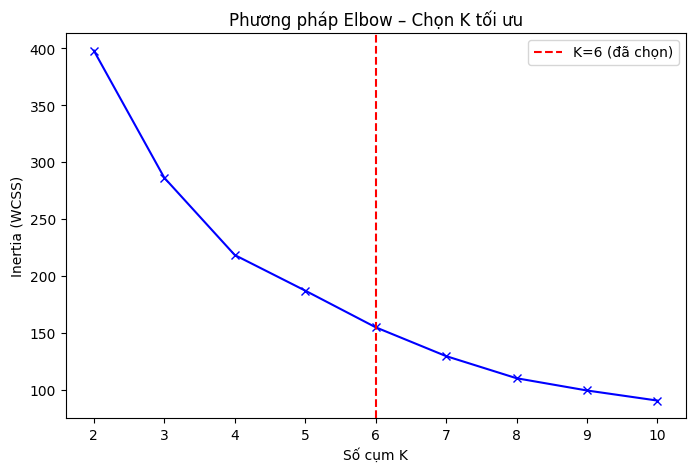

In [120]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Định nghĩa X bằng cách lấy các đặc trưng cần thiết và chuẩn hóa
features = ['passengers_2021', 'num_lines', 'lat', 'lon']
X = StandardScaler().fit_transform(df[features])

inertia_values = []
k_range = range(2, 11)  # Thử từ K=2 đến K=10
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)  # X đã được định nghĩa ở trên
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, 'bx-')
plt.xlabel('Số cụm K')
plt.ylabel('Inertia (WCSS)')
plt.title('Phương pháp Elbow – Chọn K tối ưu')
plt.axvline(x=6, color='red', linestyle='--', label='K=6 (đã chọn)')
plt.legend()
plt.show()

In [121]:
import sqlite3

# Kết nối đến database (sẽ tạo mới file nếu chưa có)
conn = sqlite3.connect("london.db")

# Lưu DataFrame 'df' vào bảng 'stations'
# index=False để không lưu cột chỉ số vào database
df.to_sql("stations", conn, if_exists="replace", index=False)

print("✓ Đã lưu dữ liệu vào london.db thành công!")
conn.close()

✓ Đã lưu dữ liệu vào london.db thành công!
